In [1]:
import catboost
import numpy as np
import pandas as pd

In [2]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow_tracking.db")

mlflow.set_experiment("CatBoost_Baseline")

<Experiment: artifact_location='/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/notebooks/mlruns/1', creation_time=1781794553131, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781794553131, lifecycle_stage='active', name='CatBoost_Baseline', tags={}, trace_location=None, workspace='default'>

In [3]:
from restaurant_visitor_eda.config import PROCESSED_DATA_DIR

df_train = pd.read_csv(PROCESSED_DATA_DIR / "train_features.csv", parse_dates=["visit_date"])
df_test = pd.read_csv(PROCESSED_DATA_DIR / "test_features.csv", parse_dates=["visit_date"])

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

2026-06-29 14:41:45.297 | INFO     | restaurant_visitor_eda.config:<module>:11 - PROJ_ROOT path is: /home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda


Train shape: (252108, 28)
Test shape: (32019, 28)


In [4]:
from restaurant_visitor_eda.features import binary_features, categorical_features, numeric_features

features = categorical_features + numeric_features + binary_features

X_full = df_train[features]
y_full = np.log1p(df_train["visitors"].values)

In [5]:
from restaurant_visitor_eda.features import get_custom_cv_splits

cv_splits = get_custom_cv_splits(df_train, n_splits=3, val_days=39)

Fold 1: Train ends 2017-03-14| Val: 2017-03-15 to 2017-04-22
Fold 2: Train ends 2017-02-03| Val: 2017-02-04 to 2017-03-14
Fold 3: Train ends 2016-12-26| Val: 2016-12-27 to 2017-02-03


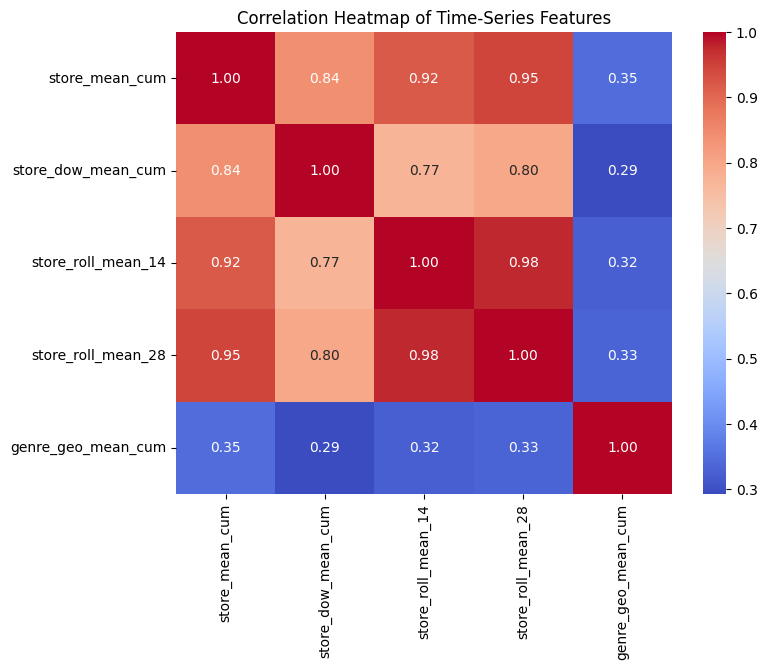

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_check = [
    "store_mean_cum",
    "store_dow_mean_cum",
    "store_roll_mean_14",
    "store_roll_mean_28",
    "genre_geo_mean_cum",
]

plt.figure(figsize=(8, 6))
sns.heatmap(df_train[cols_to_check].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Time-Series Features")
plt.show()

In [7]:
with mlflow.start_run(run_name="catboost_baseline_cv"):
    mlflow.log_param("iterations", 1500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("features_count", len(features))
    mlflow.log_param("depth", 8)
    mlflow.log_param("od_wait", 100)
    mlflow.log_param("features", features)

    cv_scores = []
    best_iterations = []

    for fold, (train_idx, val_idx) in enumerate(cv_splits):
        print(f"\n--- Fold {fold + 1} ---")

        X_train, y_train = X_full.iloc[train_idx], y_full[train_idx]
        X_val, y_val = X_full.iloc[val_idx], y_full[val_idx]

        model = catboost.CatBoostRegressor(
            iterations=1500,
            learning_rate=0.05,
            depth=8,
            loss_function="RMSE",
            eval_metric="RMSE",
            cat_features=categorical_features,
            random_seed=42,
            od_type="Iter",
            od_wait=100,
        )

        model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True, verbose=200)

        best_iter = model.get_best_iteration()
        best_score = model.get_best_score()["validation"]["RMSE"]

        best_iterations.append(best_iter)
        cv_scores.append(best_score)

        mlflow.log_metric(f"rmse_fold_{fold}", best_score)

        print(f"Fold {fold + 1} RMSLE: {best_score:.4f} (Best Iteration: {best_iter})")

    mean_rmsle = np.mean(cv_scores)

    mlflow.log_metric("mean_cv_rmse", mean_rmsle)

    mean_iterations = int(np.mean(best_iterations))

    # optimal_iterations = int(mean_iterations * (len(cv_splits) / (len(cv_splits) - 1)))

    # optimal_iterations = np.max(best_iterations)

    optimal_iterations = mean_iterations

    mlflow.log_param("optimal_iterations", optimal_iterations)

    print(f"\n[Custom Date CV] Mean RMSLE: {mean_rmsle:.4f} ± {np.std(cv_scores):.4f}")

    final_model = catboost.CatBoostRegressor(
        iterations=optimal_iterations,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        eval_metric="RMSE",
        cat_features=categorical_features,
        random_seed=42,
    )

    final_model.fit(X_full, y_full, verbose=200)
    mlflow.catboost.log_model(final_model, "model")


--- Fold 1 ---
0:	learn: 0.7820652	test: 0.7950399	best: 0.7950399 (0)	total: 121ms	remaining: 3m 1s
200:	learn: 0.5016419	test: 0.5287653	best: 0.5285797 (189)	total: 12.1s	remaining: 1m 18s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5283377297
bestIteration = 215

Shrink model to first 216 iterations.
Fold 1 RMSLE: 0.5283 (Best Iteration: 215)

--- Fold 2 ---
0:	learn: 0.7836372	test: 0.7866745	best: 0.7866745 (0)	total: 79.4ms	remaining: 1m 59s
200:	learn: 0.5036136	test: 0.4959853	best: 0.4952276 (168)	total: 13.8s	remaining: 1m 29s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4952275824
bestIteration = 168

Shrink model to first 169 iterations.
Fold 2 RMSLE: 0.4952 (Best Iteration: 168)

--- Fold 3 ---
0:	learn: 0.7837346	test: 0.8101603	best: 0.8101603 (0)	total: 78.8ms	remaining: 1m 58s
200:	learn: 0.5014978	test: 0.5008150	best: 0.5004939 (196)	total: 15.1s	remaining: 1m 37s
Stopped by overfitting detector  (100 iterations wait

2026/06/29 14:43:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


209:	learn: 0.4994643	total: 16.8s	remaining: 0us


2026/06/29 14:43:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [8]:
X_test = df_test[features]

test_preds_log = final_model.predict(X_test)

test_preds_real = np.expm1(test_preds_log)

test_preds_clipped = np.clip(test_preds_real, 1.0, None)

submission = pd.DataFrame(
    {
        "id": df_test["air_store_id"] + "_" + df_test["visit_date"].dt.strftime("%Y-%m-%d"),
        "visitors": test_preds_clipped,
    }
)

print("Minimal predicted value:", submission["visitors"].min())

submission_path = "submission_catboost_final.csv"
submission.to_csv(submission_path, index=False)

submission.head()

Minimal predicted value: 1.1471484016127032


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,4.775325
1,air_08cb3c4ee6cd6a22_2017-04-23,13.739546
2,air_f8233ad00755c35c_2017-04-23,4.796197
3,air_234d3dbf7f3d5a50_2017-04-23,7.561541
4,air_a563896da3777078_2017-04-23,29.814639


In [9]:
test_preds_round = np.round(test_preds_clipped)

submission_round = pd.DataFrame(
    {
        "id": df_test["air_store_id"] + "_" + df_test["visit_date"].dt.strftime("%Y-%m-%d"),
        "visitors": test_preds_round,
    }
)

print("Minimal predicted value:", submission_round["visitors"].min())

submission_path = "submission_catboost_final_round.csv"
submission_round.to_csv(submission_path, index=False)

submission_round.head()

Minimal predicted value: 1.0


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,5.0
1,air_08cb3c4ee6cd6a22_2017-04-23,14.0
2,air_f8233ad00755c35c_2017-04-23,5.0
3,air_234d3dbf7f3d5a50_2017-04-23,8.0
4,air_a563896da3777078_2017-04-23,30.0


/tmp/ipykernel_64361/1554427175.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance[sorted_idx], y=np.array(features)[sorted_idx], palette="viridis")


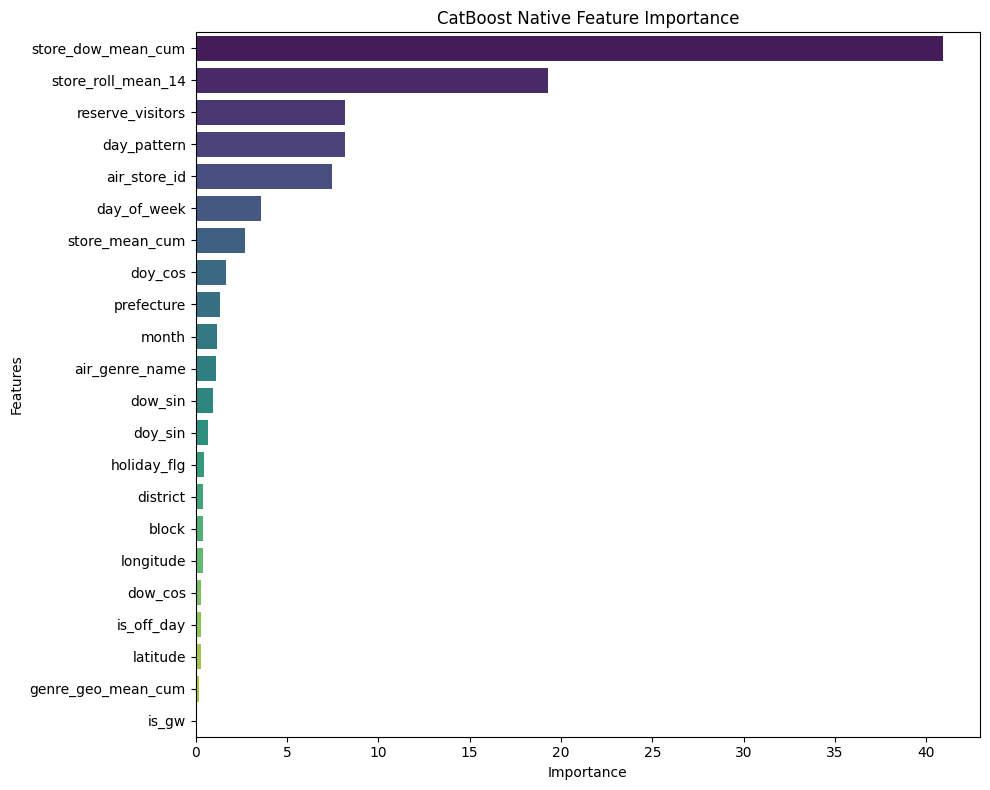

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = final_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance[sorted_idx], y=np.array(features)[sorted_idx], palette="viridis")
plt.title("CatBoost Native Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

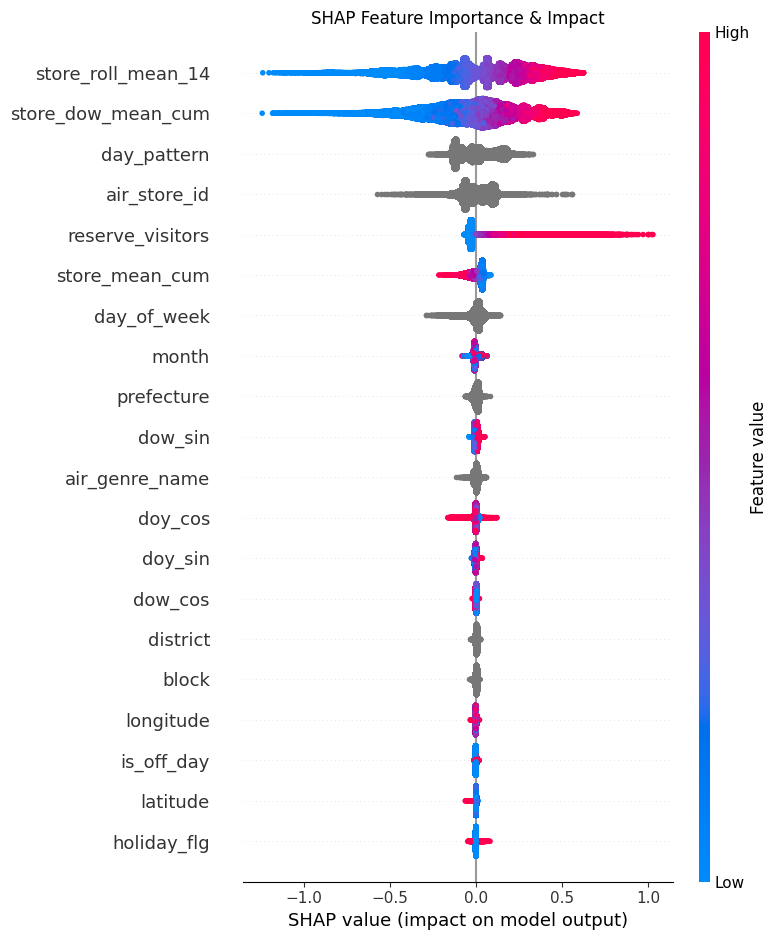

In [11]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_full)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_full, show=False)
plt.title("SHAP Feature Importance & Impact")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

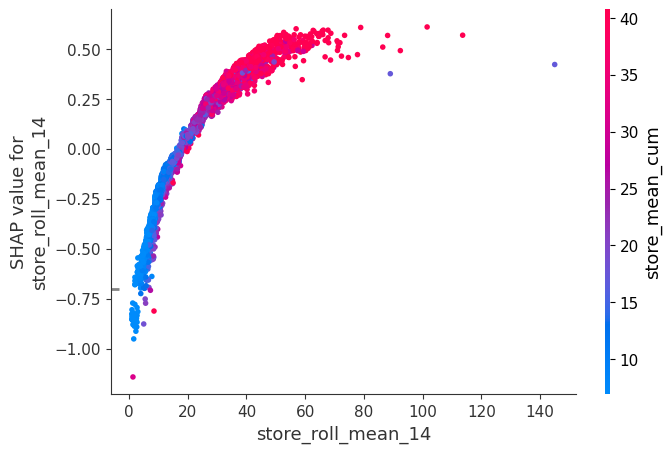

<Figure size 1000x600 with 0 Axes>

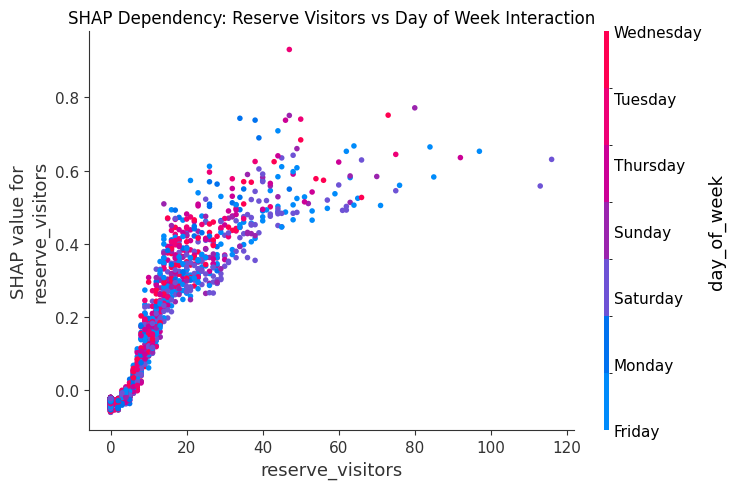

ValueError: Could not find feature named: walk_in_ratio

<Figure size 1000x600 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import shap

explainer = shap.TreeExplainer(final_model)
X_sample = X_full.sample(10000, random_state=42)
shap_values = explainer(X_sample)

plt.figure(figsize=(10, 6))
shap.dependence_plot(ind="store_roll_mean_14", shap_values=shap_values.values, features=X_sample)

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind="reserve_visitors",
    shap_values=shap_values.values,
    features=X_sample,
    interaction_index="day_of_week",
    show=False,
)
plt.title("SHAP Dependency: Reserve Visitors vs Day of Week Interaction")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind="walk_in_ratio",
    shap_values=shap_values.values,
    features=X_sample,
    interaction_index="air_genre_name",
    show=False,
)
plt.title("SHAP Dependency: Walk-in Ratio vs Genre Interaction")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind="store_dow_mean_cum",
    shap_values=shap_values.values,
    features=X_sample,
    interaction_index="holiday_flg",
    show=False,
)
plt.title("SHAP Dependency: Store DOW Mean vs Holiday Interaction")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind="genre_geo_mean_cum",
    shap_values=shap_values.values,
    features=X_sample,
    interaction_index="prefecture",
    show=False,
)
plt.title("SHAP Dependency: Genre-Geo Popularity vs Prefecture Interaction")
plt.tight_layout()
plt.show()

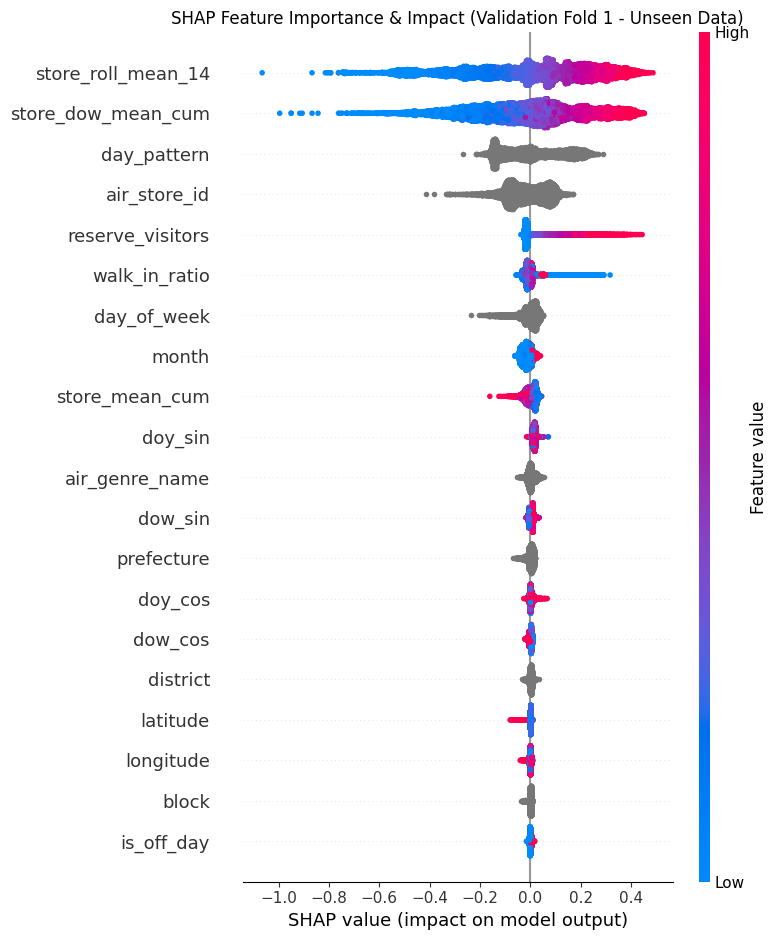

<Figure size 1000x600 with 0 Axes>

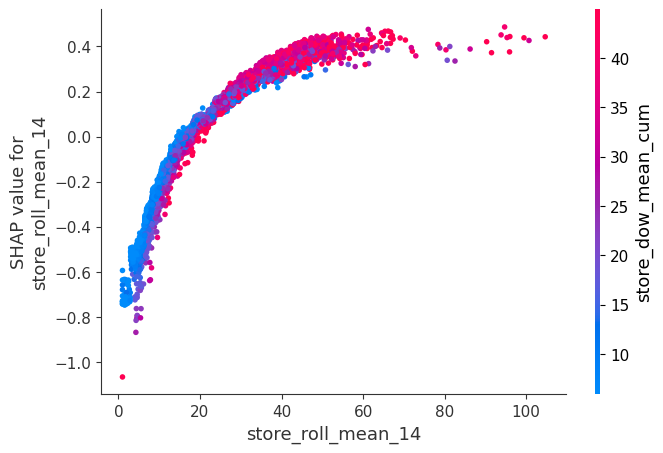

<Figure size 1000x600 with 0 Axes>

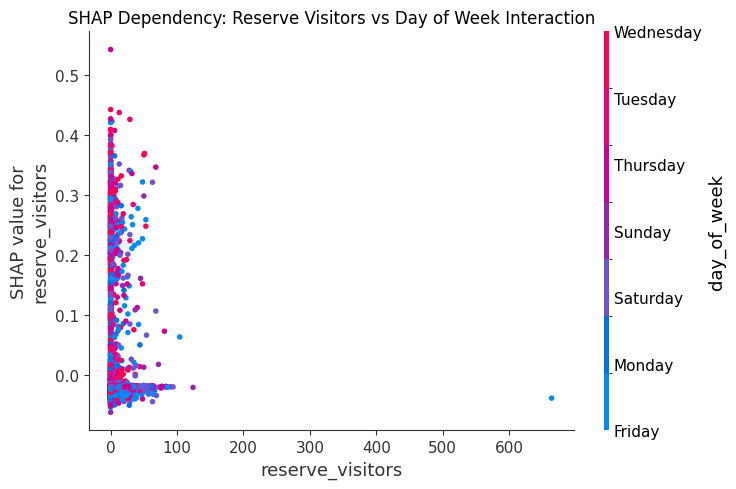

<Figure size 1000x600 with 0 Axes>

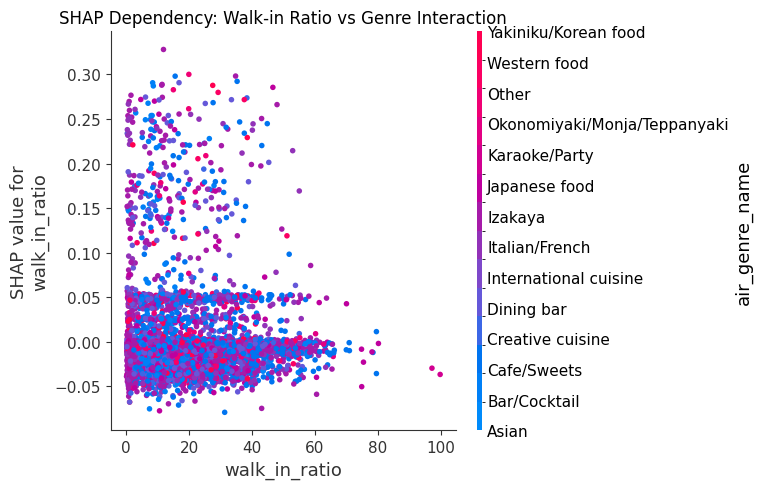

<Figure size 1000x600 with 0 Axes>

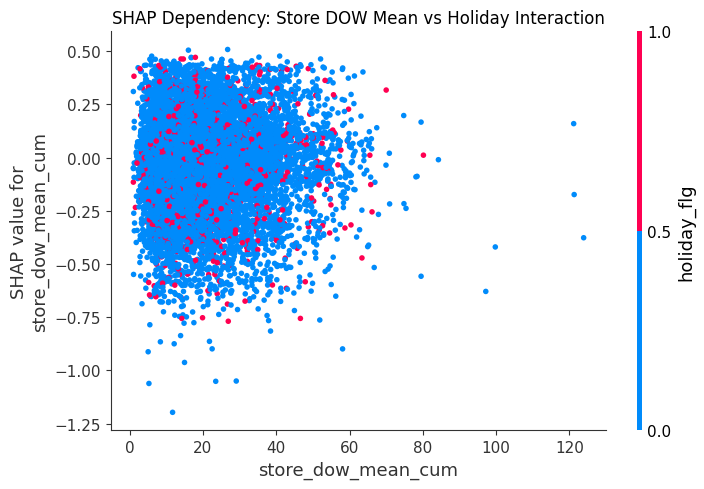

<Figure size 1000x600 with 0 Axes>

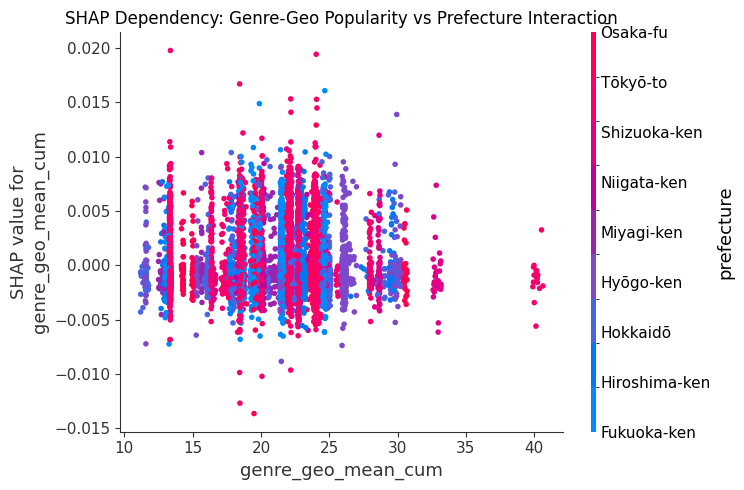

In [ ]:
train_idx, val_idx = cv_splits[0]

X_train_fold1 = X_full.iloc[train_idx]
y_train_fold1 = y_full[train_idx]

X_val_fold1 = X_full.iloc[val_idx]
y_val_fold1 = y_full[val_idx]

fold1_model = catboost.CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    cat_features=categorical_features,
    random_seed=42,
    od_type="Iter",
    od_wait=100,
)
fold1_model.fit(
    X_train_fold1,
    y_train_fold1,
    eval_set=(X_val_fold1, y_val_fold1),
    use_best_model=True,
    verbose=False,
)

explainer = shap.TreeExplainer(fold1_model)

X_val_sample = (
    X_val_fold1.sample(10000, random_state=42) if len(X_val_fold1) > 10000 else X_val_fold1
)
shap_values_val = explainer(X_val_sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_val, X_val_sample, show=False)
plt.title("SHAP Feature Importance & Impact (Validation Fold 1 - Unseen Data)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind="store_roll_mean_14", shap_values=shap_values_val.values, features=X_val_sample
)


plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind="reserve_visitors",
    shap_values=shap_values.values,
    features=X_val_sample,
    interaction_index="day_of_week",
    show=False,
)
plt.title("SHAP Dependency: Reserve Visitors vs Day of Week Interaction")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind="walk_in_ratio",
    shap_values=shap_values.values,
    features=X_val_sample,
    interaction_index="air_genre_name",
    show=False,
)
plt.title("SHAP Dependency: Walk-in Ratio vs Genre Interaction")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind="store_dow_mean_cum",
    shap_values=shap_values.values,
    features=X_val_sample,
    interaction_index="holiday_flg",
    show=False,
)
plt.title("SHAP Dependency: Store DOW Mean vs Holiday Interaction")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind="genre_geo_mean_cum",
    shap_values=shap_values.values,
    features=X_val_sample,
    interaction_index="prefecture",
    show=False,
)
plt.title("SHAP Dependency: Genre-Geo Popularity vs Prefecture Interaction")
plt.tight_layout()
plt.show()

Calculating Permutation Importance (repeats: 5, score: neg_root_mean_squared_error)...


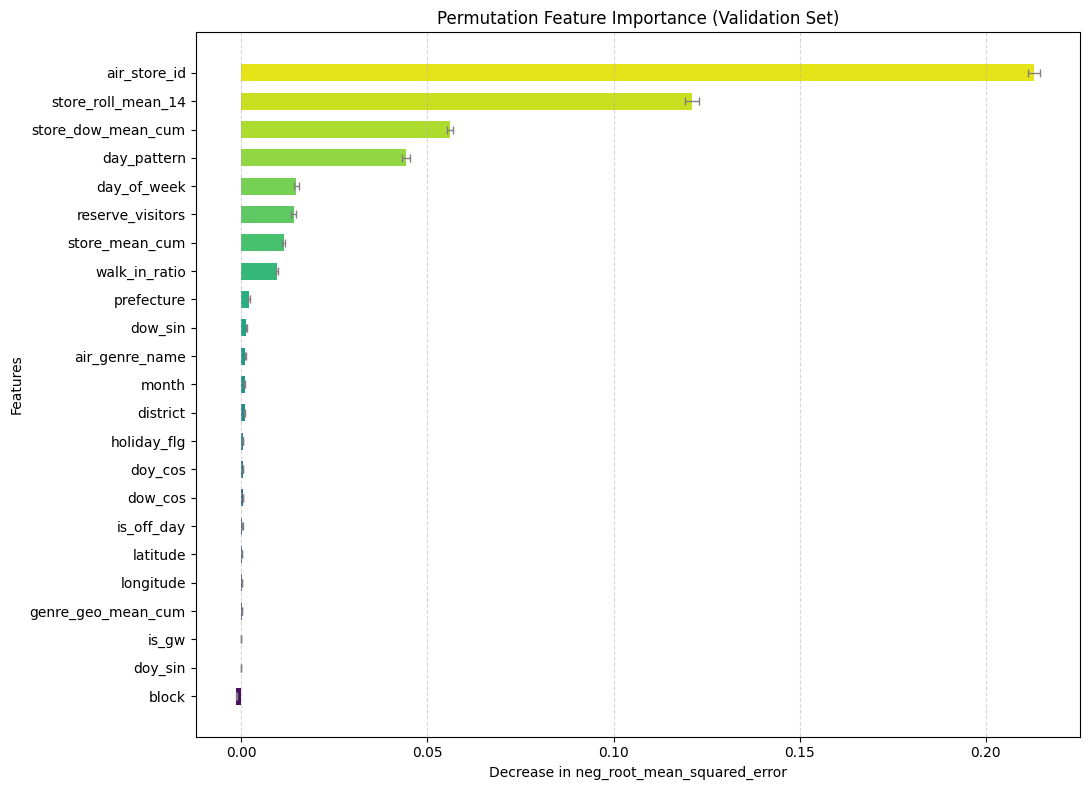

,feature,importance_mean,importance_std
0,air_store_id,0.212882,0.001646
1,store_roll_mean_14,0.121041,0.001875
2,store_dow_mean_cum,0.056095,0.000790
3,day_pattern,0.044354,0.001060
4,day_of_week,0.014797,0.000765
5,reserve_visitors,0.014087,0.000666
6,store_mean_cum,0.011354,0.000450
7,walk_in_ratio,0.009654,0.000327
8,prefecture,0.002123,0.000233
9,dow_sin,0.001379,0.000060


In [ ]:
import catboost

from restaurant_visitor_eda.plots import plot_permutation_importance

features_pfi = [f for f in features if f != "store_roll_mean_28"]

train_idx, val_idx = cv_splits[0]

X_train_fold1 = X_full.iloc[train_idx][features_pfi]
y_train_fold1 = y_full[train_idx]

X_val_fold1 = X_full.iloc[val_idx][features_pfi]
y_val_fold1 = y_full[val_idx]

model_fold1 = catboost.CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    cat_features=[c for c in categorical_features if c in features_pfi],
    random_seed=42,
    od_type="Iter",
    od_wait=100,
)
model_fold1.fit(
    X_train_fold1,
    y_train_fold1,
    eval_set=(X_val_fold1, y_val_fold1),
    use_best_model=True,
    verbose=False,
)

pfi_results = plot_permutation_importance(
    model=model_fold1, X_val=X_val_fold1, y_val=y_val_fold1, features=features_pfi, n_repeats=5
)

pfi_results.head(10)